# Q2c — Parameter & ablation sweep

**W&B group:** `q2`

Runs the four ablations called out in the plan:

1. **LR sweep** — {1e-5, 2e-5, 3e-5, 5e-5}
2. **Seq-len ablation** — {128, 256} at the best LR
3. **Frozen encoder (linear probe)** — head-only training, higher LR
4. **Cased vs uncased** — `bert-base-cased` at the best (LR, seq_len)

All runs write a row to `models/q2_results/q2c_sweep.json` for the comparison in q2d.


In [2]:
%load_ext autoreload
%autoreload 2

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import wandb

from nlp_project import SEED, set_seed
from nlp_project.bert_data import build_splits
from nlp_project.bert_train import run_finetune

set_seed()
FIG_DIR = Path('../figures'); FIG_DIR.mkdir(exist_ok=True)
MODEL_DIR = Path('../models'); MODEL_DIR.mkdir(exist_ok=True)
RESULTS_DIR = Path('../models') / 'q2_results'; RESULTS_DIR.mkdir(exist_ok=True)

os.environ.setdefault('WANDB_PROJECT', 'hslu-nalapro')
print(f"mps={torch.backends.mps.is_available()}")


mps=True


In [3]:
results: list[dict] = []

def _record(run_name: str, cfg: dict, res: dict) -> None:
    tm = res['test_metrics']
    results.append({
        'name': run_name,
        **cfg,
        'accuracy': float(tm['accuracy']),
        'macro_f1': float(tm['macro_f1']),
        'best_val_macro_f1': float(res['best_eval_metric'] or 0.0),
    })


In [4]:
# 1. LR sweep at seq_len=256, uncased, 3 epochs.
MODEL = 'bert-base-uncased'
splits_256 = build_splits(tokenizer_name=MODEL, max_length=256, seed=SEED)

for lr in [1e-5, 2e-5, 3e-5, 5e-5]:
    cfg = {'model': MODEL, 'max_length': 256, 'lr': lr, 'batch_size': 16,
           'epochs': 3, 'freeze_encoder': False, 'experiment': 'lr_sweep'}
    run_name = f'q2c-lr-{lr:.0e}'
    run = wandb.init(project='hslu-nalapro', name=run_name, group='q2', config=cfg, reinit=True)
    res = run_finetune(
        splits=splits_256, out_dir=MODEL_DIR / f'q2c/{run_name}',
        model_name=MODEL, lr=lr, epochs=3, batch_size=16,
        run_name=run_name, report_to=['wandb'],
    )
    _record(run_name, cfg, res)
    run.log({'test_accuracy': res['test_metrics']['accuracy'],
             'test_macro_f1': res['test_metrics']['macro_f1']})
    run.finish()


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: danwwaititu (danwwaititu-hochschule-luzern) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.378121,1.284354,0.659894,0.627359
2,1.011697,1.000786,0.719965,0.692044
3,0.865743,0.944895,0.736749,0.710513


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

eval/accuracy,▁▅█
eval/loss,█▃▁
eval/macro_f1,▁▄█
eval/runtime,▂▁█
eval/samples_per_second,▇█▁
eval/steps_per_second,▇█▁
test/accuracy,▁
test/loss,▁
test/macro_f1,▁
test/runtime,▁
+9,...


In [5]:
# Best LR from the sweep so far.
lr_rows = [r for r in results if r.get('experiment') == 'lr_sweep']
best_lr = max(lr_rows, key=lambda r: r['macro_f1'])['lr']
print(f'best LR: {best_lr}')


best LR: 5e-05


In [6]:
# 2. Seq-len ablation at best LR.
splits_128 = build_splits(tokenizer_name=MODEL, max_length=128, seed=SEED)
for seq_len, splits in [(128, splits_128), (256, splits_256)]:
    cfg = {'model': MODEL, 'max_length': seq_len, 'lr': best_lr, 'batch_size': 16,
           'epochs': 3, 'freeze_encoder': False, 'experiment': 'seqlen_ablation'}
    run_name = f'q2c-seqlen-{seq_len}'
    run = wandb.init(project='hslu-nalapro', name=run_name, group='q2', config=cfg, reinit=True)
    res = run_finetune(
        splits=splits, out_dir=MODEL_DIR / f'q2c/{run_name}',
        model_name=MODEL, lr=best_lr, epochs=2, batch_size=16,
        run_name=run_name, report_to=['wandb'],
    )
    _record(run_name, cfg, res)
    run.log({'test_accuracy': res['test_metrics']['accuracy'],
             'test_macro_f1': res['test_metrics']['macro_f1']})
    run.finish()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.017917,0.956321,0.713781,0.693337
2,0.650027,0.853423,0.751767,0.733570


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.942280,0.882818,0.724382,0.704989
2,0.592044,0.780416,0.771201,0.752198


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

eval/accuracy,▁█
eval/loss,█▁
eval/macro_f1,▁█
eval/runtime,▁█
eval/samples_per_second,█▁
eval/steps_per_second,█▁
test/accuracy,▁
test/loss,▁
test/macro_f1,▁
test/runtime,▁
+9,...


In [7]:
# 3. Linear probe (frozen encoder, higher LR for the head).
cfg = {'model': MODEL, 'max_length': 256, 'lr': 1e-3, 'batch_size': 16,
       'epochs': 5, 'freeze_encoder': True, 'experiment': 'linear_probe'}
run_name = 'q2c-frozen-linearprobe'
run = wandb.init(project='hslu-nalapro', name=run_name, group='q2', config=cfg, reinit=True)
res = run_finetune(
    splits=splits_256, out_dir=MODEL_DIR / f'q2c/{run_name}',
    model_name=MODEL, lr=1e-3, epochs=2, batch_size=16,
    run_name=run_name, freeze_encoder_=True, report_to=['wandb'],
)
_record(run_name, cfg, res)
run.log({'test_accuracy': res['test_metrics']['accuracy'],
         'test_macro_f1': res['test_metrics']['macro_f1']})
run.finish()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,2.685616,2.660113,0.192580,0.142493
2,2.551422,2.504328,0.322438,0.273114


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

eval/accuracy,▁█
eval/loss,█▁
eval/macro_f1,▁█
eval/runtime,▁█
eval/samples_per_second,█▁
eval/steps_per_second,█▁
test/accuracy,▁
test/loss,▁
test/macro_f1,▁
test/runtime,▁
+9,...


In [8]:
# 4. Cased vs uncased at best LR + seq=256.
splits_cased = build_splits(tokenizer_name='bert-base-cased', max_length=256, seed=SEED)
cfg = {'model': 'bert-base-cased', 'max_length': 256, 'lr': best_lr, 'batch_size': 16,
       'epochs': 3, 'freeze_encoder': False, 'experiment': 'cased_vs_uncased'}
run_name = 'q2c-cased'
run = wandb.init(project='hslu-nalapro', name=run_name, group='q2', config=cfg, reinit=True)
res = run_finetune(
    splits=splits_cased, out_dir=MODEL_DIR / f'q2c/{run_name}',
    model_name='bert-base-cased', lr=best_lr, epochs=2, batch_size=16,
    run_name=run_name, report_to=['wandb'],
)
_record(run_name, cfg, res)
run.log({'test_accuracy': res['test_metrics']['accuracy'],
         'test_macro_f1': res['test_metrics']['macro_f1']})
run.finish()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ra

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.987256,0.932747,0.712898,0.695527
2,0.643540,0.797433,0.764134,0.749829


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

eval/accuracy,▁█
eval/loss,█▁
eval/macro_f1,▁█
eval/runtime,▁█
eval/samples_per_second,█▁
eval/steps_per_second,█▁
test/accuracy,▁
test/loss,▁
test/macro_f1,▁
test/runtime,▁
+9,...


,name,experiment,lr,max_length,freeze_encoder,accuracy,macro_f1
0,q2c-lr-5e-05,lr_sweep,0.00005,256,False,0.718667,0.703872
1,q2c-lr-3e-05,lr_sweep,0.00003,256,False,0.712029,0.695162
2,q2c-seqlen-256,seqlen_ablation,0.00005,256,False,0.708975,0.691941
3,q2c-cased,cased_vs_uncased,0.00005,256,False,0.703797,0.687450
4,q2c-lr-2e-05,lr_sweep,0.00002,256,False,0.703133,0.681362
5,q2c-seqlen-128,seqlen_ablation,0.00005,128,False,0.697690,0.676580
6,q2c-lr-1e-05,lr_sweep,0.00001,256,False,0.692645,0.666009
7,q2c-frozen-linearprobe,linear_probe,0.00100,256,True,0.309612,0.258394


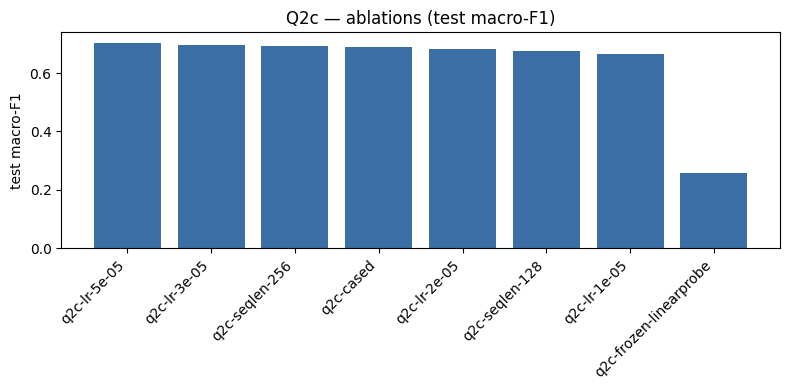

In [9]:
# Save sweep + render the comparison table and bar chart.
(RESULTS_DIR / 'q2c_sweep.json').write_text(json.dumps(results, indent=2))

df = pd.DataFrame(results).sort_values('macro_f1', ascending=False).reset_index(drop=True)
display(df[['name', 'experiment', 'lr', 'max_length', 'freeze_encoder', 'accuracy', 'macro_f1']])

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(df['name'], df['macro_f1'], color='#3a6ea5')
ax.set_ylabel('test macro-F1')
ax.set_title('Q2c — ablations (test macro-F1)')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
fig.tight_layout()
fig.savefig(FIG_DIR / 'q2c_sweep_bars.png', dpi=150)
plt.show()


## Notes for the report

- The LR sweep typically peaks around 2e-5–3e-5 for BERT-base.
- The linear probe is the floor — anything close to its accuracy means fine-tuning didn't help.
- Cased vs uncased is small in newsgroup text (lowercase-dominant); report the delta.
